In [1]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import roc_auc_score

In [2]:
vals = {}

vals['Mean Signed Error of IPCW on Censored Data'] = []
vals['Average TTE - TTC'] = []
vals['Model'] = []

vals['MAE'] = []
vals['MAE on Censored Data'] = []
vals['MAE on Uncensored Data'] = []

vals['Mean Signed Error'] = []
vals['Mean Signed Error on Censored Data'] = []
vals['Mean Signed Error on Uncensored Data'] = []


vals['Max - Avg TTE of Censored Data'] = []



all_models = ['icind',  'pcind', 'dhcind', 'proposed', 'proposed_sameweight', 'proposed_samecluster', 'proposed_assignMAX', 'oracle']
all_models_names = ['IPCW',   "Standard\nMargin", 'Standard', 'Proposed', 'Proposed Without Weight', 'Proposed Without Cluster', 'Proposed Assign Max', 'Oracle']

print(len(all_models), len(all_models_names))
for COUNT in range(1000):
    suffix = 'COUNT%d'%(COUNT)
    
    X_test = joblib.load('/data4/meerak/onevar_data/X_test_%s.joblib'%suffix).reshape(-1, 1)
    y_test = joblib.load('/data4/meerak/onevar_data/y_test_%s.joblib'%suffix)
    binary_y_test = joblib.load('/data4/meerak/onevar_data/actual_binary_y_test%s.joblib'%suffix)

    X_train = joblib.load('/data4/meerak/onevar_data/X_train_%s.joblib'%suffix).reshape(-1, 1)
    orig_y_train = joblib.load('/data4/meerak/onevar_data/orig_y_train_%s.joblib'%suffix)
    y_train = joblib.load('/data4/meerak/onevar_data/y_train_%s.joblib'%suffix)
    binary_y_train = joblib.load('/data4/meerak/onevar_data/binary_y_train_%s.joblib'%suffix)

    X_val = joblib.load('/data4/meerak/onevar_data/X_val_%s.joblib'%suffix).reshape(-1, 1)
    y_val = joblib.load('/data4/meerak/onevar_data/y_val_%s.joblib'%suffix)
    binary_y_val = joblib.load('/data4/meerak/onevar_data/binary_y_val_%s.joblib'%suffix)
    
    medcens = np.mean(np.abs(orig_y_train - y_train))

    not_exist = 0
    try:
        for model, modelname in zip(all_models, all_models_names):     
            preds = joblib.load('/data4/meerak/onevar_test_preds/%s_y_test_pred_%s.joblib'%(model, suffix))
            if len(preds) != len(y_test):
                not_exist = 1
    except:
        print(model, COUNT)
        not_exist = 1
    

    if not_exist == 0:
        for model, modelname in zip(all_models, all_models_names):
            uncensored_preds = joblib.load('/data4/meerak/onevar_test_preds/icind_y_test_pred_%s.joblib'%(suffix))
            mse_mu_ec = np.mean(uncensored_preds[binary_y_test == 0] - y_test[binary_y_test == 0])
            preds = joblib.load('/data4/meerak/onevar_test_preds/%s_y_test_pred_%s.joblib'%(model, suffix))


            vals['Mean Signed Error of IPCW on Censored Data'].append(mse_mu_ec)
            vals['Average TTE - TTC'].append(np.mean(orig_y_train[binary_y_train == 0] - y_train[binary_y_train == 0]))
            vals['Model'].append(modelname)


            vals['MAE'].append(np.mean(np.abs(preds - y_test)))
            vals['MAE on Censored Data'].append(np.mean(np.abs(preds[binary_y_test == 0] - y_test[binary_y_test == 0])))
            vals['MAE on Uncensored Data'].append(np.mean(np.abs(preds[binary_y_test == 1] - y_test[binary_y_test == 1])))
            vals['Max - Avg TTE of Censored Data'].append(max(orig_y_train[binary_y_train == 0]) - np.mean(orig_y_train[binary_y_train == 0]))

            vals['Mean Signed Error'].append(np.mean(preds - y_test))
            vals['Mean Signed Error on Censored Data'].append(np.mean(preds[binary_y_test == 0] - y_test[binary_y_test == 0]))
            vals['Mean Signed Error on Uncensored Data'].append(np.mean(preds[binary_y_test == 1] - y_test[binary_y_test == 1]))

    else:
        print(COUNT)



8 8
oracle 673
673
oracle 674
674
oracle 675
675
oracle 676
676
oracle 677
677
oracle 678
678
oracle 679
679
oracle 680
680
oracle 681
681
oracle 682
682
oracle 683
683
oracle 684
684
oracle 685
685
oracle 686
686
oracle 687
687
oracle 688
688
oracle 689
689
oracle 690
690
oracle 691
691
oracle 692
692
oracle 693
693
oracle 694
694
oracle 695
695
oracle 696
696
oracle 697
697
oracle 698
698
oracle 699
699
oracle 700
700
oracle 701
701
oracle 702
702
oracle 703
703
oracle 704
704
oracle 705
705
oracle 706
706
oracle 707
707
oracle 708
708
oracle 709
709
oracle 710
710
oracle 711
711
oracle 712
712
oracle 713
713
oracle 714
714
oracle 715
715
oracle 716
716
oracle 717
717
oracle 718
718
oracle 719
719
oracle 720
720
oracle 721
721
oracle 722
722
oracle 723
723
oracle 724
724
oracle 725
725
oracle 726
726
oracle 727
727
oracle 728
728
oracle 729
729
oracle 730
730
oracle 731
731
oracle 732
732
oracle 733
733
oracle 734
734
oracle 735
735
oracle 736
736
oracle 737
737
oracle 738
738
oracle

In [3]:
import pandas as pd
df = pd.DataFrame(vals)

In [4]:
df

,Mean Signed Error of IPCW on Censored Data,Average TTE - TTC,Model,MAE,MAE on Censored Data,MAE on Uncensored Data,Mean Signed Error,Mean Signed Error on Censored Data,Mean Signed Error on Uncensored Data,Max - Avg TTE of Censored Data
0,7.318140,10.820037,IPCW,5.798140,8.105743,1.357018,4.753749,7.318140,-0.181579,11.686920
1,7.318140,10.820037,Standard\nMargin,2.361728,2.798997,1.520175,-1.318536,-1.651322,-0.678070,11.686920
2,7.318140,10.820037,Standard,7.265447,10.353236,1.322807,6.706359,10.259344,-0.131579,11.686920
3,7.318140,10.820037,Proposed,2.280744,2.794895,1.291228,-1.424715,-2.164084,-0.001754,11.686920
4,7.318140,10.820037,Proposed Without Weight,5.789142,8.106199,1.329825,4.933113,7.318596,0.342105,11.686920
...,...,...,...,...,...,...,...,...,...,...
7379,7.098783,7.775567,Proposed,0.801140,1.072097,0.318030,-0.476005,-0.743446,0.000835,10.673299
7380,7.098783,7.775567,Proposed Without Weight,5.241452,7.884363,0.529215,4.819136,7.646536,-0.222037,10.673299
7381,7.098783,7.775567,Proposed Without Cluster,2.558188,3.686798,0.545910,-2.408218,-3.666199,-0.165275,10.673299
7382,7.098783,7.775567,Proposed Assign Max,0.894121,1.143727,0.449082,0.504799,0.790730,-0.005008,10.673299


/tmp/ipykernel_1544412/2864576994.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1544412/2864576994.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


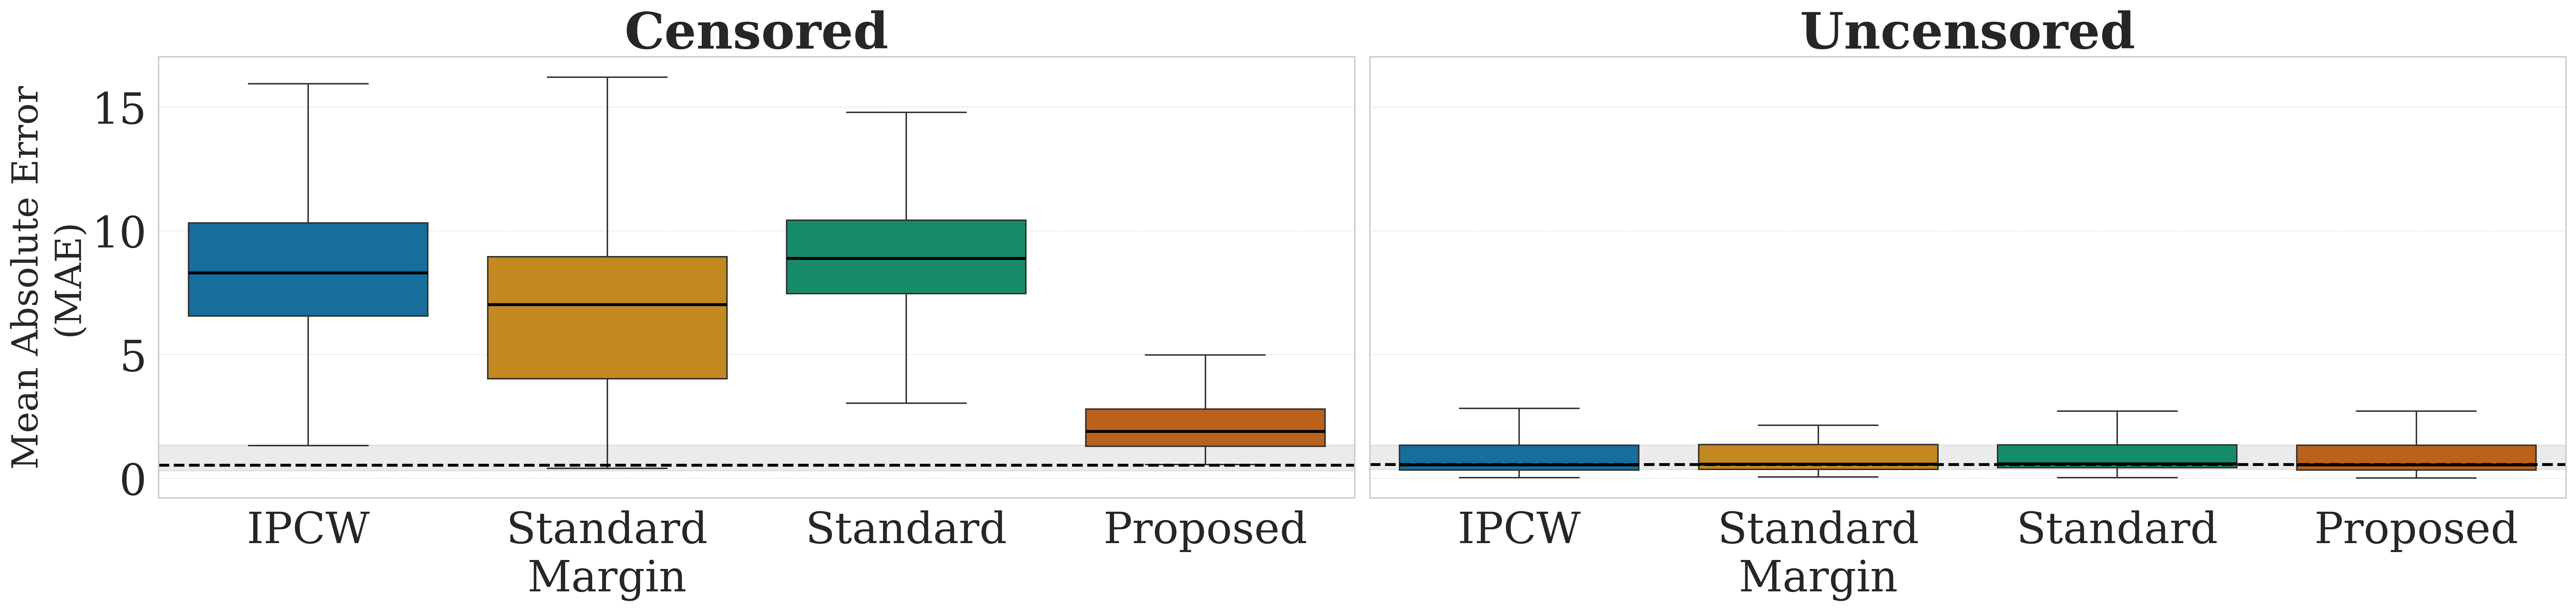

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 30,
    "figure.dpi": 300
})


method_order = ['IPCW', "Standard\nMargin", 'Standard', 'Proposed']

# Choose colors: first is for non-Proposed, second is for Proposed
palette = sns.color_palette("colorblind", n_colors=len(set(method_order)))

# Assign colors to each method based on order
method_colors = {
    method: palette[i]
    for i, method in enumerate(method_order)
}

# Compute Oracle stats
oracle_df = df[df['Model'] == 'Oracle']
oracle_cens_median = oracle_df['MAE on Censored Data'].median()
oracle_cens_ci = oracle_df['MAE on Censored Data'].quantile([0.25, 0.75]).values

oracle_uncens_median = oracle_df['MAE on Uncensored Data'].median()
oracle_uncens_ci = oracle_df['MAE on Uncensored Data'].quantile([0.25, 0.75]).values

# Remove Oracle from main plots
plot_df = df[~df['Model'].isin(['Oracle', 'Proposed Without Cluster', 'Proposed Without Weight', 'Proposed Assign Max'])]

# Set up the subplots
fig, axes = plt.subplots(1, 2, figsize=(25, 6), sharey=True)

# Censored boxplot
sns.boxplot(
    data=plot_df,
    x='Model',
    y='MAE on Censored Data',
    ax=axes[0],
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 2},
    palette = method_colors
)
axes[0].set_title('Censored', fontsize=35, weight='bold')
axes[0].set_ylabel('Mean Absolute Error\n(MAE)', fontsize=25)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.6)
axes[0].axhline(oracle_cens_median, color='black', linestyle='--', linewidth=2, label='Oracle')
axes[0].axhspan(oracle_cens_ci[0], oracle_cens_ci[1], color='black', alpha=0.08)

# Uncensored boxplot
sns.boxplot(
    data=plot_df,
    x='Model',
    y='MAE on Uncensored Data',
    ax=axes[1],
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 2},
    palette = method_colors
)
axes[1].set_title('Uncensored', fontsize=35, weight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.6)
axes[1].axhline(oracle_uncens_median, color='black', linestyle='--', linewidth=2)
axes[1].axhspan(oracle_uncens_ci[0], oracle_uncens_ci[1], color='black', alpha=0.08)

# Tight layout with no horizontal spacing
plt.subplots_adjust(wspace=0.05, top=0.88)
plt.tight_layout()
plt.savefig('synthetic.png', dpi=300)


In [6]:
for method in ['Proposed', 'Standard\nMargin', 'Standard', 'IPCW']:
    focus = df[df['Model'] == method]['MAE on Censored Data']
    print(method, '%0.2f, 95\%% CI: [%0.2f, %0.2f]'%(np.percentile(focus, 50), np.percentile(focus, 2.5), np.percentile(focus, 97.5)))

Proposed 1.89, 95\% CI: [0.74, 6.27]
Standard
Margin 7.01, 95\% CI: [1.29, 12.93]
Standard 8.89, 95\% CI: [3.74, 14.31]
IPCW 8.29, 95\% CI: [2.96, 13.83]


In [7]:
for method in ['Proposed', 'Standard\nMargin', 'Standard', 'IPCW']:
    focus = df[df['Model'] == method]['MAE on Uncensored Data']
    print(method, '%0.2f, 95\%% CI: [%0.2f, %0.2f]'%(np.percentile(focus, 50), np.percentile(focus, 2.5), np.percentile(focus, 97.5)))

Proposed 0.54, 95\% CI: [0.11, 1.87]
Standard
Margin 0.56, 95\% CI: [0.12, 8.54]
Standard 0.58, 95\% CI: [0.15, 8.31]
IPCW 0.54, 95\% CI: [0.08, 2.82]


In [8]:
for method in ['Proposed', 'Proposed Without Weight', 'Proposed Without Cluster', 'Proposed Assign Max']:
    focus = df[df['Model'] == method]['MAE on Censored Data']
    print(method, '%0.2f, 95\%% CI: [%0.2f, %0.2f]'%(np.percentile(focus, 50), np.percentile(focus, 2.5), np.percentile(focus, 97.5)))

Proposed 1.89, 95\% CI: [0.74, 6.27]
Proposed Without Weight 6.18, 95\% CI: [1.68, 11.87]
Proposed Without Cluster 6.49, 95\% CI: [2.91, 11.43]
Proposed Assign Max 1.57, 95\% CI: [0.46, 9.50]


In [9]:
for method in ['Proposed', 'Standard\nMargin', 'Standard', 'IPCW']:
    focus = df[df['Model'] == method]['Mean Signed Error on Censored Data']
    print(method, '%0.2f, 95\%% CI: [%0.2f, %0.2f]'%(np.percentile(focus, 50), np.percentile(focus, 2.5), np.percentile(focus, 97.5)))

Proposed -1.26, 95\% CI: [-4.37, 0.55]
Standard
Margin 6.07, 95\% CI: [-1.81, 12.80]
Standard 8.54, 95\% CI: [3.37, 14.24]
IPCW 5.49, 95\% CI: [-12.39, 13.58]


In [17]:
import numpy as np

def resampling_pval(x, y, n_perms=1000, metric=np.mean, alternative='less', seed=0):
    """
    Paired resampling test comparing metric(x) vs metric(y).
    Use alternative='less' to test if x < y.
    """

    rng = np.random.default_rng(seed)
    observed = metric(x) - metric(y)
    diffs = []

    for _ in range(n_perms):
        flip = rng.integers(0, 2, size=len(x))
        x_star = np.where(flip, x, y)
        y_star = np.where(flip, y, x)
        diff = metric(x_star) - metric(y_star)
        diffs.append(diff)

    diffs = np.array(diffs)
    print(np.mean(diffs <= observed))

    if alternative == 'less':
        pval = np.mean(diffs <= observed)
    elif alternative == 'greater':
        pval = np.mean(diffs >= observed)
    else:  # two-sided
        pval = np.mean(np.abs(diffs) >= abs(observed))

    return pval


baseline = 'Proposed'
baseline_vals = df[df['Model'] == baseline]['MAE on Censored Data'].values

print("MAE on Censored Data (resampling test: Proposed < Method):")
for method in ['Standard\nMargin', 'Standard', 'IPCW']:
    focus = df[df['Model'] == method]['MAE on Censored Data'].values
    median = np.percentile(focus, 50)
    ci_lower = np.percentile(focus, 2.5)
    ci_upper = np.percentile(focus, 97.5)

    # Test whether Proposed is significantly better (lower MAE) than method
    pval = resampling_pval(baseline_vals, focus, metric=np.mean, alternative='less')
    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = ''

    print(f"{method}: {median:.2f}, 95% CI: [{ci_lower:.2f}, {ci_upper:.2f}] {sig} (p = {pval:.4f})")


MAE on Censored Data (resampling test: Proposed < Method):
0.0
Standard
Margin: 7.01, 95% CI: [1.29, 12.93] *** (p = 0.0000)
0.0
Standard: 8.89, 95% CI: [3.74, 14.31] *** (p = 0.0000)
0.0
IPCW: 8.29, 95% CI: [2.96, 13.83] *** (p = 0.0000)
